# Project #5: Transportation-Project #1 Autonomous Vehicle Interactions at an Intersection (Autonomous Vehicles)
Katie Manzano, Jason Pabian, Remy Balderas

As the U.S. advances toward a future transportation system that includes autonomous vehicles (AVs) operating alongside traditional road users, understanding how these agents interact is critical. The U.S. Department of Transportation (USDOT) has tasked your team with analyzing a subset of the Third Generation Simulation (TGSIM) dataset -- specifically, the Foggy Bottom segment -- to study agent behavior around intersections.
Your objective is to evaluate the claim that AVs are generally safer and more predictable than other agents by analyzing 200 seconds of recorded trajectory data.

# Client Request: 
1. A quantitative comparison of the behavior of different 
transportation agents (e.g., AVs, non-automated passenger vehicles, 
pedestrians). Given the limited 200-second duration of the dataset, 
comparing complete trajectories may not be meaningful. Instead, 
focus on localized interactions or behavior patterns. For example:  
• Compare acceleration and deceleration patterns within 
intersection zones or near pedestrian areas approached by Avs.  
• Analyze speed profiles along specific lanes to detect consistency 
or variability between agents.  
• Measure and compare average speeds inside intersections or 
count the number of deceleration events, which may indicate 
disruptive behavior.  
• These are just a few possibilities, and there are many behavioral 
insights that can be extracted from this rich dataset.  
Present your findings using clear summary tables and visualizations 
that support your interpretations.  
2. A visual representation of agent movement at the intersection, 
either as a static plot of location vs. time or an animation that 
highlights how the agents interact over time. 

# Step #1: Prepare the environment, import necessary packages and load in our dataset. 

In [90]:
%pip install numpy
%pip install matplotlib
%pip install seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual for all our plots
sns.set_style('whitegrid')
sns.set_palette('deep')

# Load in Data Set
tgsim_Data = pd.read_csv("Transformed_TGSIM_Foggy_Bottom_200sec(in).csv")

print(tgsim_Data.head())


    id    time     xloc_kf     yloc_kf  lane_kf  speed_kf_x  speed_kf_y  \
0  165  3700.0  183.966348  308.305096       36    0.108236    6.005233   
1  165  3700.1  183.978291  308.896475       36    0.119433    5.913793   
2  165  3700.2  183.991354  309.478151       36    0.130630    5.816753   
3  165  3700.3  184.004604  310.048069       36    0.132496    5.699187   
4  165  3700.4  184.017107  310.605112       36    0.125031    5.570423   

   acceleration_kf_x  acceleration_kf_y  length_smoothed  width_smoothed  \
0           0.018661           0.802440             15.0        2.413078   
1           0.111968          -0.914408             15.0        2.413078   
2           0.111968          -0.970392             15.0        2.413078   
3           0.018661          -1.175667             15.0        2.413078   
4          -0.074646          -1.287635             15.0        2.413078   

   type_most_common  
0                 7  
1                 7  
2                 7  
3   

# Step #2: Cleaning & Organizing Data 
* Check for missing values
* Remove NAs in the database
* Replace NAs-Imputation

In [91]:
# Locate NAs in the Transformed TGSIM Foggy Bottom 200sec database

In [92]:
tgsim_Data = pd.read_csv("Transformed_TGSIM_Foggy_Bottom_200sec(in).csv", low_memory = True)
tgsim_Data = pd.DataFrame(tgsim_Data)

print(tgsim_Data.isna())

          id   time  xloc_kf  yloc_kf  lane_kf  speed_kf_x  speed_kf_y  \
0      False  False    False    False    False       False       False   
1      False  False    False    False    False       False       False   
2      False  False    False    False    False       False       False   
3      False  False    False    False    False       False       False   
4      False  False    False    False    False       False       False   
...      ...    ...      ...      ...      ...         ...         ...   
71356  False  False    False    False    False       False       False   
71357  False  False    False    False    False       False       False   
71358  False  False    False    False    False       False       False   
71359  False  False    False    False    False       False       False   
71360  False  False    False    False    False       False       False   

       acceleration_kf_x  acceleration_kf_y  length_smoothed  width_smoothed  \
0                  False       

In [93]:
# View shape and sample rows

In [94]:
tgsim_Data.shape #rows and columns
tgsim_Data.head() 
tgsim_Data.info() # types
tgsim_Data.describe(include = 'all') # summary stats

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71361 entries, 0 to 71360
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 71361 non-null  int64  
 1   time               71361 non-null  float64
 2   xloc_kf            71361 non-null  float64
 3   yloc_kf            71361 non-null  float64
 4   lane_kf            71361 non-null  int64  
 5   speed_kf_x         71361 non-null  float64
 6   speed_kf_y         71361 non-null  float64
 7   acceleration_kf_x  71361 non-null  float64
 8   acceleration_kf_y  71361 non-null  float64
 9   length_smoothed    71361 non-null  float64
 10  width_smoothed     71361 non-null  float64
 11  type_most_common   71361 non-null  int64  
dtypes: float64(9), int64(3)
memory usage: 6.5 MB


,id,time,xloc_kf,yloc_kf,lane_kf,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,type_most_common
count,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000,71361.000000
mean,4738.010860,3801.804675,81.131044,266.847530,25.789479,-0.121062,-0.723644,0.004984,-0.011585,4.503755,1.390293,2.416096
std,5232.987271,55.535699,56.068695,73.696055,14.171178,1.717602,4.483481,0.417142,0.862168,3.047355,0.924573,1.642860
min,165.000000,3700.000000,0.018848,134.375960,1.000000,-12.488198,-21.540835,-5.691722,-8.658882,0.000000,0.000000,0.000000
25%,1668.000000,3759.400000,38.951907,169.729205,14.000000,-0.110102,-0.042921,-0.055984,-0.055984,0.000000,0.000000,0.000000
50%,1705.000000,3800.600000,48.622236,307.943252,29.000000,-0.001866,0.001866,0.000000,0.000000,6.197281,1.691488,3.000000
75%,6522.000000,3845.700000,129.268712,326.582242,38.000000,0.018661,0.182882,0.055984,0.055984,6.200000,2.200000,3.000000
max,19268.000000,3900.000000,196.837478,357.065053,49.000000,14.055754,17.556630,4.422748,6.120934,15.000000,2.750000,7.000000


In [95]:
# Use pandas with sep parameter

In [96]:
tgsim_Data = pd.read_csv("Transformed_TGSIM_Foggy_Bottom_200sec(in).csv", sep = ';', encoding = 'utf-8')

In [97]:
# Locate NAs

In [98]:
data = {'col1': [1, 2, np.nan, 4], 'col2': [5, np.nan, 7, 8]}
tgsim_Data = pd.DataFrame(data)

print(tgsim_Data.isna())

tgsim_Data = pd.read_csv("Transformed_TGSIM_Foggy_Bottom_200sec(in).csv", low_memory = True)
tgsim_Data = pd.DataFrame(tgsim_Data)

print(tgsim_Data.isna())

    col1   col2
0  False  False
1  False   True
2   True  False
3  False  False
          id   time  xloc_kf  yloc_kf  lane_kf  speed_kf_x  speed_kf_y  \
0      False  False    False    False    False       False       False   
1      False  False    False    False    False       False       False   
2      False  False    False    False    False       False       False   
3      False  False    False    False    False       False       False   
4      False  False    False    False    False       False       False   
...      ...    ...      ...      ...      ...         ...         ...   
71356  False  False    False    False    False       False       False   
71357  False  False    False    False    False       False       False   
71358  False  False    False    False    False       False       False   
71359  False  False    False    False    False       False       False   
71360  False  False    False    False    False       False       False   

       acceleration_kf_x  accel

In [99]:
# Remove NAs

In [100]:
tgsim_Data_dropped = tgsim_Data.dropna()

tgsim_Data_dropped_columns = tgsim_Data.dropna(axis = 1)

print(tgsim_Data_dropped_columns)


          id    time     xloc_kf     yloc_kf  lane_kf  speed_kf_x  speed_kf_y  \
0        165  3700.0  183.966348  308.305096       36    0.108236    6.005233   
1        165  3700.1  183.978291  308.896475       36    0.119433    5.913793   
2        165  3700.2  183.991354  309.478151       36    0.130630    5.816753   
3        165  3700.3  184.004604  310.048069       36    0.132496    5.699187   
4        165  3700.4  184.017107  310.605112       36    0.125031    5.570423   
...      ...     ...         ...         ...      ...         ...         ...   
71356  19268  3886.5  175.087448  168.982190        4    0.156756   -1.282037   
71357  19268  3886.6  175.103124  168.853986        4    0.156756   -1.282037   
71358  19268  3886.7  175.118986  168.725783        4    0.158622   -1.282037   
71359  19268  3886.8  175.133915  168.605790        4    0.149291   -1.199927   
71360  19268  3886.9  175.146978  168.489903        4    0.130630   -1.158872   

       acceleration_kf_x  a

In [101]:
# Imputation-Replace NA values with 0

In [102]:
tgsim_Data_filled_0 = tgsim_Data.fillna(0)

print(tgsim_Data_filled_0)

          id    time     xloc_kf     yloc_kf  lane_kf  speed_kf_x  speed_kf_y  \
0        165  3700.0  183.966348  308.305096       36    0.108236    6.005233   
1        165  3700.1  183.978291  308.896475       36    0.119433    5.913793   
2        165  3700.2  183.991354  309.478151       36    0.130630    5.816753   
3        165  3700.3  184.004604  310.048069       36    0.132496    5.699187   
4        165  3700.4  184.017107  310.605112       36    0.125031    5.570423   
...      ...     ...         ...         ...      ...         ...         ...   
71356  19268  3886.5  175.087448  168.982190        4    0.156756   -1.282037   
71357  19268  3886.6  175.103124  168.853986        4    0.156756   -1.282037   
71358  19268  3886.7  175.118986  168.725783        4    0.158622   -1.282037   
71359  19268  3886.8  175.133915  168.605790        4    0.149291   -1.199927   
71360  19268  3886.9  175.146978  168.489903        4    0.130630   -1.158872   

       acceleration_kf_x  a

In [103]:
tgsim_Data.shape
tgsim_Data.isna().sum()

id                   0
time                 0
xloc_kf              0
yloc_kf              0
lane_kf              0
speed_kf_x           0
speed_kf_y           0
acceleration_kf_x    0
acceleration_kf_y    0
length_smoothed      0
width_smoothed       0
type_most_common     0
dtype: int64

In [104]:
# Export Cleaned Data 

In [105]:
tgsim_Data.to_csv("Cleaned_Transformed_TGSIM_Foggy_Bottom_200sec(in).csv", index = False)

# Step #3: Organized Data Columns & Seperate Agent Types

In [106]:
# Make sure time, speed, and acceleration values are numeric 

In [107]:
tgsim_Data.columns

Index(['id', 'time', 'xloc_kf', 'yloc_kf', 'lane_kf', 'speed_kf_x',
       'speed_kf_y', 'acceleration_kf_x', 'acceleration_kf_y',
       'length_smoothed', 'width_smoothed', 'type_most_common'],
      dtype='object')

In [108]:
print(tgsim_Data.dtypes)

id                     int64
time                 float64
xloc_kf              float64
yloc_kf              float64
lane_kf                int64
speed_kf_x           float64
speed_kf_y           float64
acceleration_kf_x    float64
acceleration_kf_y    float64
length_smoothed      float64
width_smoothed       float64
type_most_common       int64
dtype: object


In [109]:
# Converting time from a float to an integer

In [110]:
tgsim_Data['time'] = tgsim_Data['time'].astype(int)
print(tgsim_Data['time'].dtypes)

int32


In [111]:
# Converting speed from float to integer

In [112]:
tgsim_Data['speed_kf_x'] = tgsim_Data['speed_kf_x'].astype(int) # speed_kf_x
print(tgsim_Data['speed_kf_x'].dtypes)

int32


In [113]:
tgsim_Data['speed_kf_y'] = tgsim_Data['speed_kf_y'].astype(int) # speed_kf_y
print(tgsim_Data['speed_kf_y'].dtypes)

int32


In [114]:
# Converting acceleration from float to integer

In [115]:
tgsim_Data['acceleration_kf_x'] = tgsim_Data['acceleration_kf_x'].astype(int) # acceleration_kf_x
print(tgsim_Data['acceleration_kf_x'].dtypes)

int32


In [116]:
tgsim_Data['acceleration_kf_y'] = tgsim_Data['acceleration_kf_y'].astype(int) # acceleration_kf_y
print(tgsim_Data['acceleration_kf_y'].dtypes)

int32


In [117]:
# Check everything converted 

In [118]:
print(tgsim_Data.dtypes)

id                     int64
time                   int32
xloc_kf              float64
yloc_kf              float64
lane_kf                int64
speed_kf_x             int32
speed_kf_y             int32
acceleration_kf_x      int32
acceleration_kf_y      int32
length_smoothed      float64
width_smoothed       float64
type_most_common       int64
dtype: object


# Step #4: Confirm Coordinate Frames using Polygon Data

In [119]:
polygons = {
    1: [(30.324748770225, 331.53814563188763), (57.663676123074, 331.53814563188763), (57.663676123074, 316.0118742615324), (30.324748770225, 316.0118742615324)],
    2: [(175.21173304839542, 330.9783041161296), (179.2799147295702, 337.9390002953874), (191.839026066408, 337.9390002953874), (191.839026066408, 313.6792012792074), (178.9253484362568, 309.5363740625982), (175.21173304839542, 315.9745514938152)],
    3: [(28.92514498083, 170.9009533770588), (52.25187480408, 170.9009533770588), (52.25187480408, 155.9718462901788), (28.92514498083, 155.9718462901788)],
    4: [(174.8385053712234, 169.8559158809772), (178.3655069204988, 173.55086988498), (191.22320039907422, 171.6474087314028), (191.22320039907422, 155.3000364712692), (177.749681253165, 155.8785393708858)],
    5: [(41.521579085385, 361.9935240891228), (45.4031469279738, 361.9935240891228), (45.253855857105, 337.864354759953), (41.334965246799, 337.864354759953)],
    6: [(41.3722880145162, 309.4803899110224), (40.8870920341926, 177.0592100503968), (44.7686598767814, 177.0592100503968), (45.2165330893878, 309.4803899110224)],
    7: [(40.6631554278894, 149.2724094849414), (44.246141128740604, 149.2724094849414), (43.7236223806998, -0.0186613838586), (40.1406366798486, -0.0186613838586)],
    8: [(45.4031469279738, 361.9935240891228), (48.8368415579562, 361.9935240891228), (48.6502277193702, 337.864354759953), (45.253855857105, 337.864354759953)],
    9: [(45.2165330893878, 309.4803899110224), (44.7686598767814, 177.0592100503968), (48.5382594162186, 177.0592100503968), (48.986132628825004, 309.4803899110224)],
    10: [(47.9784179004606, 149.2724094849414), (47.399915000844004, -0.0186613838586), (43.7236223806998, -0.0186613838586), (44.246141128740604, 149.2724094849414)],
    11: [(52.3078589556558, 361.9935240891228), (52.0092768139182, 337.864354759953), (48.6502277193702, 337.864354759953), (48.8368415579562, 361.9935240891228)],
    12: [(51.9346312784838, 177.0592100503968), (52.345181723373, 309.4803899110224), (48.986132628825004, 309.4803899110224), (48.5382594162186, 177.0592100503968)],
    13: [(47.9784179004606, 149.2724094849414), (51.5614036013118, 149.2724094849414), (51.1881759241398, -0.0186613838586), (47.399915000844004, -0.0186613838586)],
    14: [(41.521579085385, 361.9935240891228), (41.334965246799, 337.864354759953), (37.3414291010586, 337.864354759953), (37.6400112427962, 361.9935240891228)],
    15: [(41.3722880145162, 309.4803899110224), (40.8870920341926, 177.0592100503968), (36.8935558884522, 177.0592100503968), (37.3041063333414, 309.4803899110224)],
    16: [(40.6631554278894, 149.2724094849414), (40.1406366798486, -0.0186613838586), (36.3710371404114, -0.0186613838586), (36.9308786561694, 149.2724094849414)],
    17: [(33.683797864773, 361.9935240891228), (33.497184026187, 337.864354759953), (37.3414291010586, 337.864354759953), (37.6400112427962, 361.9935240891228)],
    18: [(33.030649429722, 177.0592100503968), (33.6464750970558, 309.4803899110224), (37.3041063333414, 309.4803899110224), (36.8935558884522, 177.0592100503968)],
    19: [(36.9308786561694, 149.2724094849414), (36.3710371404114, -0.0186613838586), (32.8253742072774, -0.0186613838586), (33.1986018844494, 149.2724094849414)],
    20: [(33.683797864773, 361.9935240891228), (33.497184026187, 337.864354759953), (30.511362608811, 337.864354759953), (30.79128336669, 361.9935240891228)],
    21: [(33.030649429722, 177.0592100503968), (33.6464750970558, 309.4803899110224), (30.138134931639, 309.4803899110224), (29.764907254467, 177.0592100503968)],
    22: [(33.1986018844494, 149.2724094849414), (32.8253742072774, -0.0186613838586), (29.4663251127294, -0.0186613838586), (29.764907254467, 149.2724094849414)],
    23: [(179.14928504256, 302.7249689542092), (182.88156181428, 303.9566202888768), (182.6576252079768, 177.9549564756096), (178.7387345976708, 178.589443526802)],
    24: [(178.5521207590848, 151.250516173953), (182.6203024402596, 151.063902335367), (182.2470747630876, 66.8264155976466), (178.21621584963, 66.8264155976466)],
    25: [(182.88156181428, 303.9566202888768), (187.4349394757784, 305.486853765282), (187.1363573340408, 177.2458238889828), (182.6576252079768, 177.9549564756096)],
    26: [(182.6203024402596, 151.063902335367), (186.50187028284842, 151.1198864869428), (186.2032881411108, 66.8264155976466), (182.2470747630876, 66.8264155976466)],
    27: [(187.4349394757784, 305.486853765282), (191.652412227822, 306.9051189385356), (191.465798389236, 176.5740140700732), (187.1363573340408, 177.2458238889828)],
    28: [(186.50187028284842, 151.1198864869428), (190.6446974994576, 150.7653201936294), (190.3834381254372, 66.8264155976466), (186.2032881411108, 66.8264155976466)],
    29: [(168.512296243158, 330.6423992066748), (168.512296243158, 323.8496554821444), (64.56838815075601, 323.7003644112756), (64.56838815075601, 330.8476744291194)],
    30: [(168.512296243158, 323.8496554821444), (168.512296243158, 316.2358108678356), (64.56838815075601, 316.2358108678356), (64.56838815075601, 323.7003644112756)],
    31: [(0.0186613838586, 169.2400902136434), (22.300353711027, 169.2400902136434), (22.300353711027, 163.193801843457), (0.0186613838586, 163.193801843457)],
    32: [(169.7066248101084, 169.538672355381), (171.0502444479276, 163.4177384497602), (59.063279912469, 163.4177384497602), (59.063279912469, 169.538672355381)],
    33: [(0.0186613838586, 163.193801843457), (22.300353711027, 163.193801843457), (22.300353711027, 157.2968045441394), (0.0186613838586, 157.2968045441394)],
    34: [(171.0502444479276, 163.4177384497602), (172.3192185503124, 156.9235768669674), (59.063279912469, 156.9235768669674), (59.063279912469, 163.4177384497602)],
    35: [(178.402829688216, 337.9390002953874), (192.21225374358, 337.9390002953874), (192.21225374358, 344.8437123230694), (178.402829688216, 344.8437123230694)],
    36: [(178.9253484362568, 309.5363740625982), (191.839026066408, 313.6792012792074), (191.839026066408, 307.0357486255458), (178.9253484362568, 302.6689848026334)],
    37: [(175.21173304839542, 330.9783041161296), (175.21173304839542, 315.9745514938152), (168.512296243158, 315.9745514938152), (168.512296243158, 330.9783041161296)],
    38: [(191.839026066408, 331.8740505413424), (196.87759970823, 331.8740505413424), (196.87759970823, 314.2390427949654), (191.839026066408, 314.2390427949654)],
    39: [(29.764907254467, 331.53814563188763), (53.744785512768004, 331.53814563188763), (53.744785512768004, 337.864354759953), (29.764907254467, 337.864354759953)],
    40: [(29.764907254467, 316.0118742615324), (53.744785512768004, 316.0118742615324), (53.744785512768004, 309.4803899110224), (29.764907254467, 309.4803899110224)],
    41: [(57.663676123074, 331.53814563188763), (64.56838815075601, 331.53814563188763), (64.56838815075601, 315.5453396650674), (57.663676123074, 315.5453396650674)],
    42: [(178.3655069204988, 173.55086988498), (192.77209525933802, 171.4607948928168), (192.77209525933802, 176.3314160799114), (178.3655069204988, 178.57078214294341)],
    43: [(177.749681253165, 155.8785393708858), (191.745719147115, 155.3000364712692), (191.652412227822, 150.7653201936294), (177.8803109401752, 151.250516173953)],
    44: [(191.22320039907422, 170.5837098514626), (195.90720774758282, 170.7889850739072), (195.90720774758282, 155.3000364712692), (191.22320039907422, 155.3000364712692)],
    45: [(174.8385053712234, 169.8559158809772), (177.469760495286, 156.4383808866438), (172.5058323888984, 156.4383808866438), (169.6693020423912, 169.8559158809772)],
    46: [(28.92514498083, 170.9009533770588), (52.625102481252, 170.9009533770588), (52.625102481252, 177.0592100503968), (28.92514498083, 177.0592100503968)],
    47: [(28.738531142244, 155.9718462901788), (52.625102481252, 155.9718462901788), (52.625102481252, 149.2724094849414), (28.738531142244, 149.2724094849414)],
    48: [(52.25187480408, 170.0425297195632), (59.063279912469, 170.0425297195632), (59.063279912469, 156.4570422705024), (52.25187480408, 156.4570422705024)],
    49: [(28.92514498083, 170.3597732451594), (28.92514498083, 156.2704284319164), (22.300353711027, 156.2704284319164), (22.300353711027, 170.3597732451594)],
}
    

In [120]:
import json, ast, re
from pathlib import Path

In [121]:
# Find File Location

In [122]:
import os
os.getcwd()

'/drive/CIVE 202/Project #5'

In [123]:
NOTEBOOK_PATH = "/drive/CIVE 202/Project #5/Polygons.ipynb"

nb = json.loads(Path(NOTEBOOK_PATH).read_text())

def find_polygons_literal(nb_json):
    for cell in nb_json.get("cells", []):
        if cell.get("cell_type") != "code":
            continue
        src = "".join(cell.get("source", []))
        m = re.search(r"(^|\n)\s*polygons\s*=\s*(\{.*)", src, flags=re.S)
        if m:
            rhs = m.group(2)
            start = rhs.find("{")
            if start >= 0:
                depth = 0
                for i, ch in enumerate(rhs[start:], start):
                    if ch == "{":
                        depth += 1
                    elif ch == "}":
                        depth -= 1
                        if depth == 0:
                            literal = rhs[start:i+1]
                            try:
                                return ast.literal_eval(literal)
                            except Exception as e:
                                print("literal_eval failed:", e)
                                return None
    return None

polygons = find_polygons_literal(nb)
if polygons is None:
    raise RuntimeError("Could not find a literal polygons = {...} in the notebook.")
print("Loaded", len(polygons), "polygons from notebook")


print(type(polygons))
print("count:", len(polygons))
for pid, verts in list(polygons.items())[:5]:
    print("pid:", pid, "n_verts:", len(verts), "sample:", verts[:5])

Loaded 49 polygons from notebook
<class 'dict'>
count: 49
pid: 1 n_verts: 4 sample: [(30.324748770225, 331.53814563188763), (57.663676123074, 331.53814563188763), (57.663676123074, 316.0118742615324), (30.324748770225, 316.0118742615324)]
pid: 2 n_verts: 6 sample: [(175.21173304839542, 330.9783041161296), (179.2799147295702, 337.9390002953874), (191.839026066408, 337.9390002953874), (191.839026066408, 313.6792012792074), (178.9253484362568, 309.5363740625982)]
pid: 3 n_verts: 4 sample: [(28.92514498083, 170.9009533770588), (52.25187480408, 170.9009533770588), (52.25187480408, 155.9718462901788), (28.92514498083, 155.9718462901788)]
pid: 4 n_verts: 5 sample: [(174.8385053712234, 169.8559158809772), (178.3655069204988, 173.55086988498), (191.22320039907422, 171.6474087314028), (191.22320039907422, 155.3000364712692), (177.749681253165, 155.8785393708858)]
pid: 5 n_verts: 4 sample: [(41.521579085385, 361.9935240891228), (45.4031469279738, 361.9935240891228), (45.253855857105, 337.86435475

In [124]:
# Data Check

In [125]:
tgsim_Data.head()

,id,time,xloc_kf,yloc_kf,lane_kf,speed_kf_x,speed_kf_y,acceleration_kf_x,acceleration_kf_y,length_smoothed,width_smoothed,type_most_common
0,165,3700,183.966348,308.305096,36,0,6,0,0,15.0,2.413078,7
1,165,3700,183.978291,308.896475,36,0,5,0,0,15.0,2.413078,7
2,165,3700,183.991354,309.478151,36,0,5,0,0,15.0,2.413078,7
3,165,3700,184.004604,310.048069,36,0,5,0,-1,15.0,2.413078,7
4,165,3700,184.017107,310.605112,36,0,5,0,-1,15.0,2.413078,7


In [126]:
tgsim_Data.columns

Index(['id', 'time', 'xloc_kf', 'yloc_kf', 'lane_kf', 'speed_kf_x',
       'speed_kf_y', 'acceleration_kf_x', 'acceleration_kf_y',
       'length_smoothed', 'width_smoothed', 'type_most_common'],
      dtype='object')

In [127]:
# X and Y Ranges
print("point x range:", tgsim_Data["xloc_kf"].min(), tgsim_Data["xloc_kf"].max())
print("point y range:", tgsim_Data["yloc_kf"].min(), tgsim_Data["yloc_kf"].max())

point x range: 0.018847998 196.8374777
point y range: 134.3759598 357.0650526


In [128]:
# Polygon Numeric Ranges and Centroids

In [129]:
import math, statistics

poly_ranges = {}
for pid, verts in polygons.items():
    xs = [p[0] for p in verts]
    ys = [p[1] for p in verts]
    poly_ranges[pid] = {
        "xmin": min(xs), "xmax": max(xs),
        "ymin": min(ys), "ymax": max(ys),
        "centroid": (statistics.mean(xs), statistics.mean(ys))
    }

# Polygon Bounds
xmin = min(v["xmin"] for v in poly_ranges.values())
xmax = max(v["xmax"] for v in poly_ranges.values())
ymin = min(v["ymin"] for v in poly_ranges.values())
ymax = max(v["ymax"] for v in poly_ranges.values())

print("polygons count:", len(polygons))
print("polygons bbox x:", xmin, "to", xmax)
print("polygons bbox y:", ymin, "to", ymax)



polygons count: 49
polygons bbox x: 0.0186613838586 to 196.87759970823
polygons bbox y: -0.0186613838586 to 361.9935240891228


In [130]:
print("Columns:", list(tgsim_Data.columns))
print("dtype time:", tgsim_Data['time'].dtype)
print("xloc min/max:", tgsim_Data['xloc_kf'].min(), tgsim_Data['xloc_kf'].max())
print("yloc min/max:", tgsim_Data['yloc_kf'].min(), tgsim_Data['yloc_kf'].max())
print("Unique types:", tgsim_Data['type_most_common'].unique())
# compute polygon bboxes to compare
def poly_bbox(poly):
    arr = np.asarray(poly, dtype=float)
    return arr[:,0].min(), arr[:,0].max(), arr[:,1].min(), arr[:,1].max()
bboxes = {pid: poly_bbox(coords) for pid, coords in polygons.items()}
xs = [b[0] for b in bboxes.values()] + [b[1] for b in bboxes.values()]
ys = [b[2] for b in bboxes.values()] + [b[3] for b in bboxes.values()]
print("polygons x min/max:", min(xs), max(xs))
print("polygons y min/max:", min(ys), max(ys))


Columns: ['id', 'time', 'xloc_kf', 'yloc_kf', 'lane_kf', 'speed_kf_x', 'speed_kf_y', 'acceleration_kf_x', 'acceleration_kf_y', 'length_smoothed', 'width_smoothed', 'type_most_common']
dtype time: int32
xloc min/max: 0.018847998 196.8374777
yloc min/max: 134.3759598 357.0650526
Unique types: [7 3 6 4 5 0 1 2]
polygons x min/max: 0.0186613838586 196.87759970823
polygons y min/max: -0.0186613838586 361.9935240891228


# Step #5: Label Groups Columns

In [131]:
col = "type_most_common"
vals = tgsim_Data[col].unique()
print("Raw uniques:", vals[:200])
print("Types present:", {type(v) for v in vals})
print("\nCounts:\n", tgsim_Data[col].value_counts(dropna=False).head(50))

Raw uniques: [7 3 6 4 5 0 1 2]
Types present: {<class 'numpy.int64'>}

Counts:
 type_most_common
3    47143
0    18290
7     2724
4     1975
1      498
6      495
2      210
5       26
Name: count, dtype: int64


In [132]:
GROUP_COL = "type_most_common"
AV_CODE = 7
VEHICLE_CODE = 2

avs = tgsim_Data[tgsim_Data[GROUP_COL] == AV_CODE]
vehicles = tgsim_Data[tgsim_Data[GROUP_COL] == VEHICLE_CODE]

In [133]:
# Sample Rows

In [134]:
GROUP_COL = "type_most_common"
for code in sorted(tgsim_Data[GROUP_COL].unique()):
    print("===")
    print("Code:", code, " Count:", int((tgsim_Data[GROUP_COL]==code).sum()))
    display(tgsim_Data.loc[tgsim_Data[GROUP_COL]==code, 
                           ["id", "time", "xloc_kf", "yloc_kf", GROUP_COL]].head(5))

===
Code: 0  Count: 18290


,id,time,xloc_kf,yloc_kf,type_most_common
52363,6487,3700,175.538867,324.747828,0
52364,6487,3700,175.528043,324.883496,0
52365,6487,3700,175.516847,325.019538,0
52366,6487,3700,175.504717,325.157632,0
52367,6487,3700,175.492773,325.298525,0


===
Code: 1  Count: 498


,id,time,xloc_kf,yloc_kf,type_most_common
53318,6519,3806,177.561948,321.531912,1
53319,6519,3806,177.414150,321.703783,1
53320,6519,3807,177.266165,321.875841,1
53321,6519,3807,177.118180,322.047899,1
53322,6519,3807,176.970195,322.219770,1


===
Code: 2  Count: 210


...

,id,time,xloc_kf,yloc_kf,type_most_common
35065,1703,3842,46.591690,326.081184,5
35066,1703,3843,47.024448,325.936371,5
35067,1703,3843,47.475680,325.780549,5
35068,1703,3843,47.945574,325.614276,5
35069,1703,3843,48.433942,325.437926,5


===
Code: 6  Count: 495


,id,time,xloc_kf,yloc_kf,type_most_common
13736,1653,3700,48.620556,308.126693,6
13737,1653,3700,48.621676,308.127253,6
13738,1653,3700,48.623169,308.127626,6
13739,1653,3700,48.624475,308.127999,6
13740,1653,3700,48.625968,308.128186,6


===
Code: 7  Count: 2724


,id,time,xloc_kf,yloc_kf,type_most_common
0,165,3700,183.966348,308.305096,7
1,165,3700,183.978291,308.896475,7
2,165,3700,183.991354,309.478151,7
3,165,3700,184.004604,310.048069,7
4,165,3700,184.017107,310.605112,7


In [135]:
# Mapping Codes

In [136]:
mapping = {
    7: "AV",
    3: "non-AV",
    1: "Pedestrian",
}

In [137]:
# Counts after mapping for each group

In [138]:
tgsim_Data = tgsim_Data.copy() #copying the database ensures it isn't destroyed
tgsim_Data["group_label"] = tgsim_Data[GROUP_COL].map(mapping).fillna("other")

print('Counts after mapping:"')
print(tgsim_Data['group_label'].value_counts(dropna = False))

Counts after mapping:"
group_label
non-AV        47143
other         20996
AV             2724
Pedestrian      498
Name: count, dtype: int64


In [139]:
# Sample Rows

In [140]:

print("\nSample of 'other' codes:")
print(tgsim_Data.loc[tgsim_Data["group_label"]=="other", GROUP_COL].value_counts().head(20))
display(tgsim_Data.loc[tgsim_Data["group_label"]=="other",
                       ["id", "time", "xloc_kf", "yloc_kf", GROUP_COL]].head(20))


Sample of 'other' codes:
type_most_common
0    18290
4     1975
6      495
2      210
5       26
Name: count, dtype: int64


,id,time,xloc_kf,yloc_kf,type_most_common
13736,1653,3700,48.620556,308.126693,6
13737,1653,3700,48.621676,308.127253,6
13738,1653,3700,48.623169,308.127626,6
13739,1653,3700,48.624475,308.127999,6
13740,1653,3700,48.625968,308.128186,6
13741,1653,3700,48.627647,308.128559,6
13742,1653,3700,48.629140,308.128559,6
13743,1653,3700,48.630633,308.128559,6
13744,1653,3700,48.631193,308.128186,6
13745,1653,3700,48.631193,308.127626,6


# Step #5: Find Speed and Acceleration Magnitudes

In [141]:
tgsim_Data = tgsim_Data.copy()

In [142]:
# We need to compute the total speed (magnitude) of the data set 

tgsim_Data['speed_mag'] = np.sqrt(tgsim_Data['speed_kf_x']**2 + tgsim_Data['speed_kf_y']**2)

tgsim_Data['acc_mag'] = np.sqrt(tgsim_Data['acceleration_kf_x']**2 + tgsim_Data['acceleration_kf_y']**2)


In [143]:
# Create a "Fast" Indicator

In [144]:
FAST_THRESH = -0.5  # units same as speed columns
tgsim_Data["is_fast"] = tgsim_Data["speed_mag"] > FAST_THRESH

In [145]:
# Summary Tables

In [146]:
GROUP_COL = "type_most_common"

summary = tgsim_Data.groupby(GROUP_COL).agg(
    n_rows = ("id", "count"),
    n_ids = ("id", "nunique"),
    median_v = ("speed_mag", "median"),
    median_a = ("acc_mag", "median"),
    frac_fast = ("is_fast", "mean"),
)

summary = summary.sort_values("n_rows", ascending = False)
print(summary.head())

                  n_rows  n_ids  median_v  median_a  frac_fast
type_most_common                                              
3                  47143    157       0.0       0.0        1.0
0                  18290    380       1.0       0.0        1.0
7                   2724      7       0.0       0.0        1.0
4                   1975      1       2.0       0.0        1.0
1                    498      8       0.0       0.0        1.0


In [147]:
# Observations: 
# Code 3 has the largest amount of rows but has no velocity or acceleration. Implying its mostly stationary or non-vehicles, most likely pedestrians.
# Code 0 has many rows and most unique ids but no acceleration. Implies very low speed samples.
# Code 7 has small sample sizes but with no velocity and acceleration aligning with low speeds.
# Code 4 shows vehicle like signs with only one unique id
# Code 1 has the smallest values

In [148]:
GROUP_COL = "type_most_common"

summary = tgsim_Data.groupby(GROUP_COL).agg(
    n_rows = ("id", "count"),
    n_ids = ("id", "nunique"),
    median_v = ("speed_mag", "median"),
    median_a = ("acc_mag", "median"),
    frac_fast = ("is_fast", "mean"),
)

summary = summary.sort_values("n_rows", ascending = False)
print(summary)

                  n_rows  n_ids  median_v  median_a  frac_fast
type_most_common                                              
3                  47143    157   0.00000       0.0        1.0
0                  18290    380   1.00000       0.0        1.0
7                   2724      7   0.00000       0.0        1.0
4                   1975      1   2.00000       0.0        1.0
1                    498      8   0.00000       0.0        1.0
6                    495      2   0.00000       0.0        1.0
2                    210      8   4.00000       1.0        1.0
5                     26      1   5.09902       1.0        1.0


# Step 6: Scatter Plots

In [149]:
# Analysis: All points, Colored Samples, and Polygon bboxes

Rows in tgsim_Data: 71361

Coordinate Columns:
      xloc_kf     yloc_kf
0  183.966348  308.305096
1  183.978291  308.896475
2  183.991354  309.478151
3  184.004604  310.048069
4  184.017107  310.605112
xloc_kf range: 0.0188 to 197
yloc_kf range: 134 to 357

Code Counts:
type_most_common
3    47143
0    18290
7     2724
4     1975
1      498
6      495
2      210
5       26
Name: count, dtype: int64

Number of POLYGONS parsed: 0


<ipython-input-150-2c98a30f98c8>:52: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df.groupby('type_most_common', group_keys=False).apply(lambda g: g.sample(min(len(g),500), random_state=1)).reset_index(drop=True)


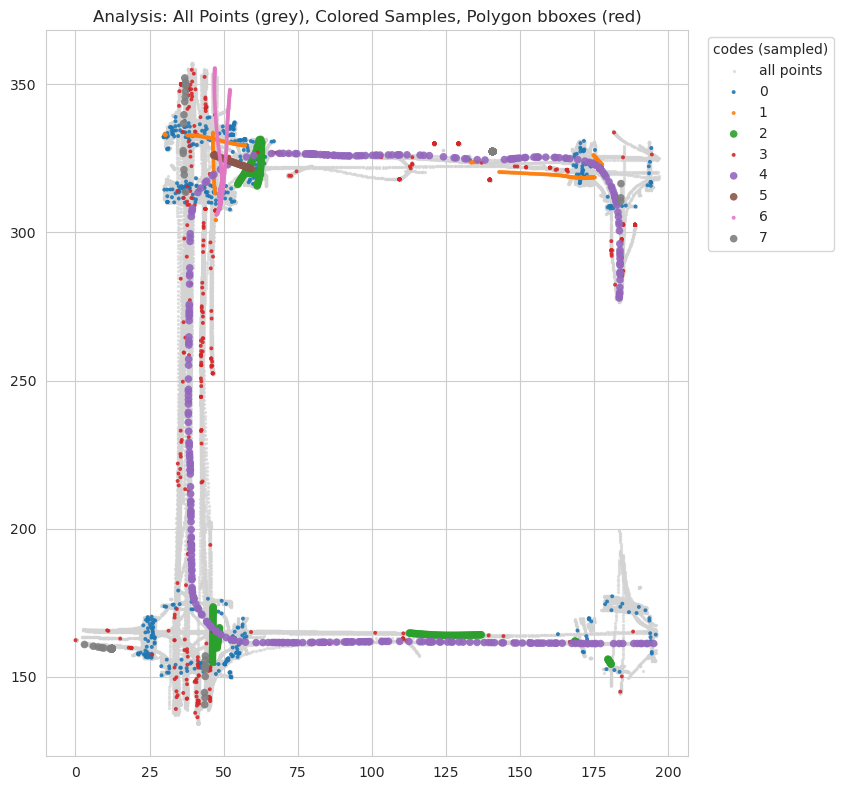

In [150]:
DF_NAME = 'tgsim_Data'
POLY_VAR = 'polygons'

df = globals()[DF_NAME]
polys = globals()[POLY_VAR]

print("Rows in tgsim_Data:", len(df))
expected_cols = ['id','xloc_kf','yloc_kf','type_most_common','speed_kf_x','speed_kf_y','acceleration_kf_x','acceleration_kf_y']

#coordinate samples
print("\nCoordinate Columns:")
print(df[['xloc_kf','yloc_kf']].head(5))

# ranges
for c in ['xloc_kf','yloc_kf']:
    if c in df.columns:
        col = df[c].dropna()
        if len(col)==0:
            print(f"Column {c} has zero non-NaN values.")
        else:
            print(f"{c} range: {col.min():.3g} to {col.max():.3g}")

if 'type_most_common' in df.columns:
    print("\nCode Counts:")
    print(df['type_most_common'].value_counts().head(20))
else:
    print("\nNo type_most_common column found.")

POLYGONS = []
for el in polys:
    a = np.asarray(el)
    if a.ndim == 2 and a.shape[1] >= 2:
        POLYGONS.append(a[:,:2])
    else:
        try:
            coords = np.array(el.exterior.coords)[:, :2]
            POLYGONS.append(coords)
        except Exception:
            pass
print("\nNumber of POLYGONS parsed:", len(POLYGONS))
if len(POLYGONS)>0:
    all_x = np.hstack([p[:,0] for p in POLYGONS])
    all_y = np.hstack([p[:,1] for p in POLYGONS])
    print("Polygons bbox x:", all_x.min(), all_x.max(), " y:", all_y.min(), all_y.max())

fig, ax = plt.subplots(figsize=(8,8))

if 'xloc_kf' in df.columns and 'yloc_kf' in df.columns:
    ax.scatter(df['xloc_kf'], df['yloc_kf'], s=2, color='lightgrey', alpha=0.6, label='all points')

if 'type_most_common' in df.columns:
    sampled = df.groupby('type_most_common', group_keys=False).apply(lambda g: g.sample(min(len(g),500), random_state=1)).reset_index(drop=True)
    codes = sorted(sampled['type_most_common'].astype(int).unique())
    cmap = plt.get_cmap('tab10')
    for i,code in enumerate(codes):
        g = sampled[sampled['type_most_common']==code]
        s = 30 if code in (2,4,5,7) else 8
        ax.scatter(g['xloc_kf'], g['yloc_kf'], s=s, color=cmap(i%10), label=str(code), alpha=0.9, edgecolors='none')

# polygon bounding boxes 
for poly in POLYGONS:
    p = np.asarray(poly)
    minx, maxx = p[:,0].min(), p[:,0].max()
    miny, maxy = p[:,1].min(), p[:,1].max()
    rect_x = [minx, maxx, maxx, minx, minx]
    rect_y = [miny, miny, maxy, maxy, miny]
    ax.plot(rect_x, rect_y, color='red', linewidth=0.8, alpha=0.8)

ax.legend(title='codes (sampled)', bbox_to_anchor=(1.02,1), loc='upper left')
ax.set_title('Analysis: All Points (grey), Colored Samples, Polygon bboxes (red)')
ax.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()


In [151]:
# Polygon Outlines and Code Emphasis 

<ipython-input-152-6af180f80509>:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled = df.groupby('type_most_common', group_keys=False).apply(lambda g: g.sample(min(len(g),500), random_state=1)).reset_index(drop=True)


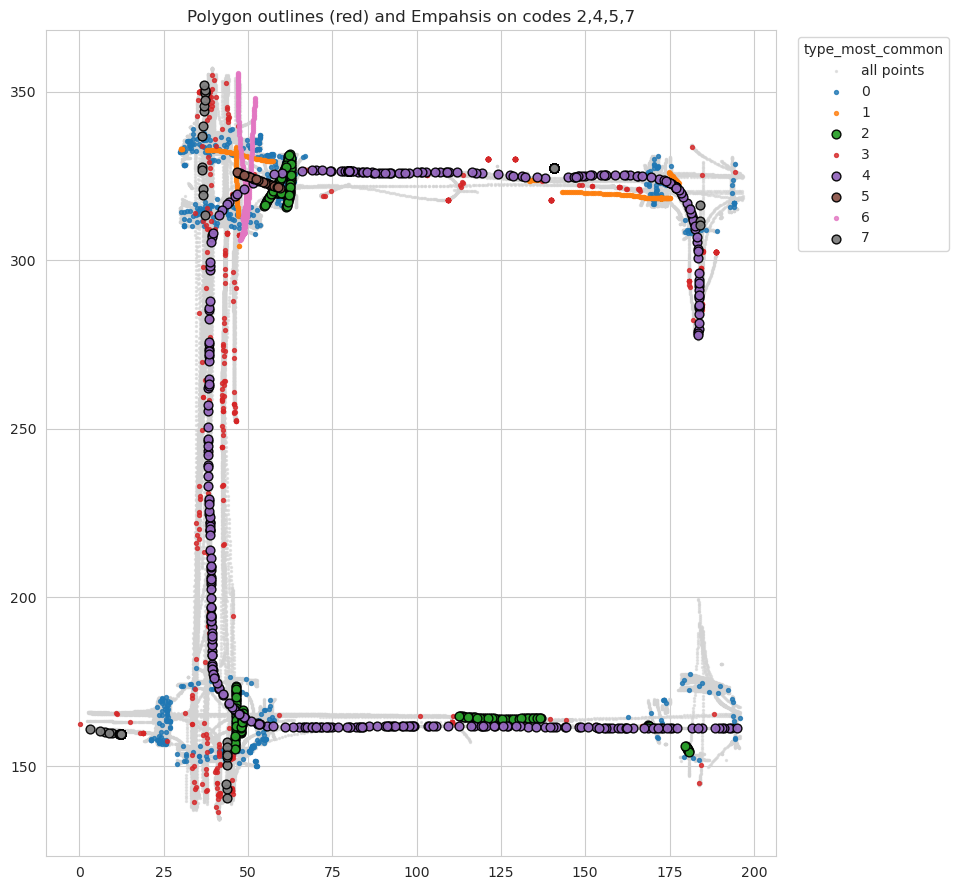

In [152]:
df = tgsim_Data.copy()   

sampled = df.groupby('type_most_common', group_keys=False).apply(lambda g: g.sample(min(len(g),500), random_state=1)).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9,9))

for poly in POLYGONS: #polygon 
    p = np.asarray(poly)
    ax.plot(p[:,0], p[:,1], color='red', linewidth=0.9, alpha=0.9)

# all points (grey)
if 'xloc_kf' in df.columns and 'yloc_kf' in df.columns:
    ax.scatter(df['xloc_kf'], df['yloc_kf'], s=2, color='lightgrey', alpha=0.6, label='all points')

# emphasize selected codes
EMPH = {2,4,5,7}
cmap = plt.get_cmap('tab10')
codes = sorted(sampled['type_most_common'].astype(int).unique())
for i,code in enumerate(codes):
    g = sampled[sampled['type_most_common']==code]
    if code in EMPH:
        s = 40
        edge = 'k'
        z = 5
        alpha = 0.95
    else:
        s = 8
        edge = None
        z = 3
        alpha = 0.8
    ax.scatter(g['xloc_kf'], g['yloc_kf'], s=s, color=cmap(i%10), label=str(code), alpha=alpha, edgecolors=edge, zorder=z)

ax.legend(title='type_most_common', bbox_to_anchor=(1.02,1), loc='upper left')
ax.set_aspect('equal', adjustable='box')
plt.title('Polygon outlines (red) and Empahsis on codes 2,4,5,7')
plt.tight_layout()
plt.show()


In [153]:
# These scatter plots prove spatial overalap. Meaning the points do fall in the outlined polygon intersections (grey) and shows important codes. It also shows us the high-magnitude decceleration events. These are the clusters or large points.  

# Step #7: Creating New Columns

In [154]:
# Locate Dataframe
import pandas as pd
for name,obj in globals().items():
    if isinstance(obj,pd.DataFrame):
        print("Aliasing", name, "-> df, shape=", obj.shape)
        df = obj
        break


Aliasing __ -> df, shape= (5, 12)


In [167]:
# Create Speed column
df['_speed'] = (df['speed_kf_x'].astype(float)**2 + df['speed_kf_y'].astype(float)**2)**0.5

In [187]:
# Check Columns
print("columns:", df.columns)
print("\nhead (transposed): \n", df.head(1).T)

columns: Index(['id', 'time', 'xloc_kf', 'yloc_kf', 'lane_kf', 'speed_kf_x',
       'speed_kf_y', 'acceleration_kf_x', 'acceleration_kf_y',
       'length_smoothed', 'width_smoothed', 'type_most_common', 'dt', '_speed',
       'inside_poly', '_accel', '_decel', 'is_harsh', '_group'],
      dtype='object')

head (transposed): 
                             0
id                        165
time                   3700.0
xloc_kf            183.966348
yloc_kf            308.305096
lane_kf                    36
speed_kf_x           0.108236
speed_kf_y           6.005233
acceleration_kf_x    0.018661
acceleration_kf_y     0.80244
length_smoothed          15.0
width_smoothed       2.413078
type_most_common            7
dt                        NaN
_speed               6.006209
inside_poly             False
_accel                    NaN
_decel                   -0.0
is_harsh                 True
_group                     AV


In [188]:
# Check Speed column has been added
speed_col = '_speed'

df['_speed'] = df[speed_col].astype(float)   
print("_speed sample:", df['_speed'].iloc[:5].tolist())

_speed sample: [6.006208649141761, 5.914998433865284, 5.818219971626068, 5.700726566606504, 5.571826103842107]


In [189]:
# Now confirm polygons
polys = globals().get('POLYGONS', [])
print("POLYGONS in globals:", 'POLYGONS' in globals(), "n_polygons=", len(polys))


POLYGONS in globals: True n_polygons= 0


In [190]:
# Create tag point column (tag points tell us points made inside the polygon)
from matplotlib.path import Path
polys = globals().get('POLYGONS', [])

pts = df[['xloc_kf','yloc_kf']].values
inside = np.zeros(len(df), dtype=bool)
for p in polys:
    inside |= Path(np.asarray(pts)[:,:2]).contains_points(pts)
df['inside_poly'] = inside
print("There are these points inside polygon:", int(df['inside_poly'].sum()), "/", len(df))



There are these points inside polygon: 0 / 71361


# Step #8: Find Harsh Events 

In [191]:
# Speed differences per vehicle
df = df.sort_values(['id','time']).copy()
df['_accel'] = df.groupby('id')['_speed'].diff()
df['_decel'] = -np.minimum(df['_accel'].fillna(0.0),0.0)
print(df[['_speed', 'time', '_accel', '_decel']].head().to_string(index = False))

  _speed   time    _accel    _decel
6.006209 3700.0       NaN -0.000000
5.914998 3700.1 -0.091210  0.091210
5.818220 3700.2 -0.096778  0.096778
5.700727 3700.3 -0.117493  0.117493
5.571826 3700.4 -0.128900  0.128900


In [192]:
# Identify the total Harsh events occured and the groups 

HARSH_THRESH =  -0.5
df['is_harsh'] = df['_decel'].fillna(0) >= HARSH_THRESH

def label_code(x):
    try:
        xi = int(x)
    except:
        return 'other'
    if xi == 7: return 'AV'
    if xi == 3: return 'non_AV'
    if xi == 1: return 'pedestrian'
    return 'other'

df['_group'] = df['type_most_common'].apply(label_code)
print("Total Harsh Events:", int(df['is_harsh'].sum()))
print("Total Harsh Events Inside Polygons:", int(df.loc[df['inside_poly'],'is_harsh'].sum()))
print("Count of Groups:\n", df['_group'].value_counts().to_dict())


Total Harsh Events: 71361
Total Harsh Events Inside Polygons: 0
Count of Groups:
 {'non_AV': 47143, 'other': 20996, 'AV': 2724, 'pedestrian': 498}


# Step #9: Find consistencies of braking for large vs. small vehicles near pedestrian zones

In [195]:
# Sort and compute dt and dv per vehicle
tgsim_Data = pd.read_csv('Transformed_TGSIM_Foggy_Bottom_200sec(in).csv')
tgsim_Data = tgsim_Data.sort_values(['id', 'time'])
tgsim_Data['dt'] = df.groupby('id')['time'].diff()
tgsim_Data['dv'] = df.groupby('id')['_speed'].diff()
tgsim_Data = tgsim_Data.dropna(subset =['dt','dv'])

In [196]:
# Acceleration
tgsim_Data['accel_fd'] = tgsim_Data['dv'] / tgsim_Data['dt']


In [199]:
# Compute KF Acceleration along velocity
vx = tgsim_Data['speed_kf_x'].fillna(0)
vy = tgsim_Data['speed_kf_y'].fillna(0)
vmag = np.sqrt(vx**2 +vy**2).replace(0, np.nan)
tgsim_Data['accel_along_v'] = (tgsim_Data['acceleration_kf_x'] * vx + tgsim_Data['acceleration_kf_y'] * vy) / vmag


tgsim_Data['accel_used'] = tgsim_Data['accel_along_v'].fillna(tgsim_Data['accel_fd'])

In [200]:
# Classify Vehicle Sizes from Length
tgsim_Data['veh_size'] = pd.cut(tgsim_Data['length_smoothed'],
                                bins = [-1,4.5,6.0, 100],
                                labels = ['small', 'medium', 'large'])

In [205]:
# Decceletations of vehicles
peak = tgsim_Data.groupby('id')['accel_used'].min().reset_index().rename(columns = {'accel_used' : 'peak_decel'})
sizes = tgsim_Data[['id', 'veh_size']].drop_duplicates(subset = 'id')
peak = peak.merge(sizes, on = 'id', how = 'left')

<ipython-input-206-f6c96116b9e9>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(peak.groupby('veh_size')['peak_decel'].agg(['count','mean','median','std']))


          count      mean    median       std
veh_size                                     
small       399 -0.614670 -0.538474  0.840748
medium       18 -2.558304 -2.537304  0.873826
large       123 -3.229809 -3.396431  1.513224


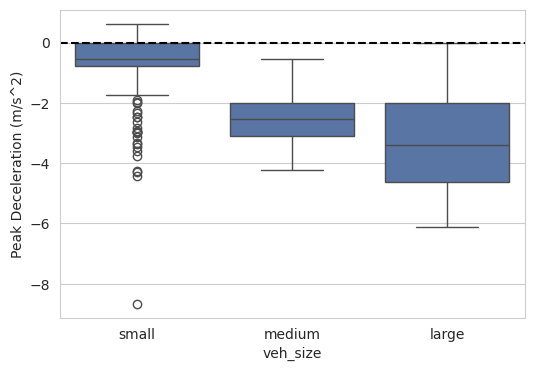

In [206]:
# Boxplot Summary
print(peak.groupby('veh_size')['peak_decel'].agg(['count','mean','median','std']))
plt.figure(figsize = (6,4))
sns.boxplot(x = 'veh_size', y = 'peak_decel', data = peak, order = ['small','medium','large'])
plt.axhline(0, color= 'k', linestyle = '--')
plt.ylabel('Peak Deceleration (m/s^2)')
plt.show()